In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore') # This hides those "FutureWarnings"

# Loading Sudan
df = pd.read_csv("data/sudan_clean.csv")

# Quick check to ensure it's loaded
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1


In [2]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,6.423564
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,3.477046
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,12.000000


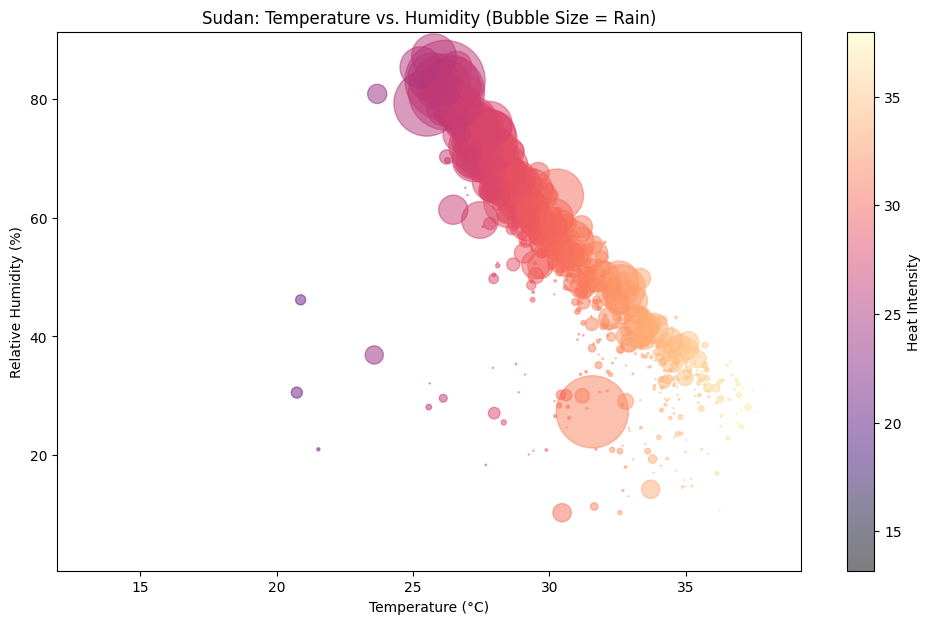

In [3]:
plt.figure(figsize=(12, 7))
plt.scatter(
    x=df['T2M'], 
    y=df['RH2M'], 
    s=df['PRECTOTCORR'] * 50, 
    c=df['T2M'], 
    cmap='magma', # Magma is great for showing "heat"
    alpha=0.5
)
plt.title('Sudan: Temperature vs. Humidity (Bubble Size = Rain)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.colorbar(label='Heat Intensity')
plt.show()

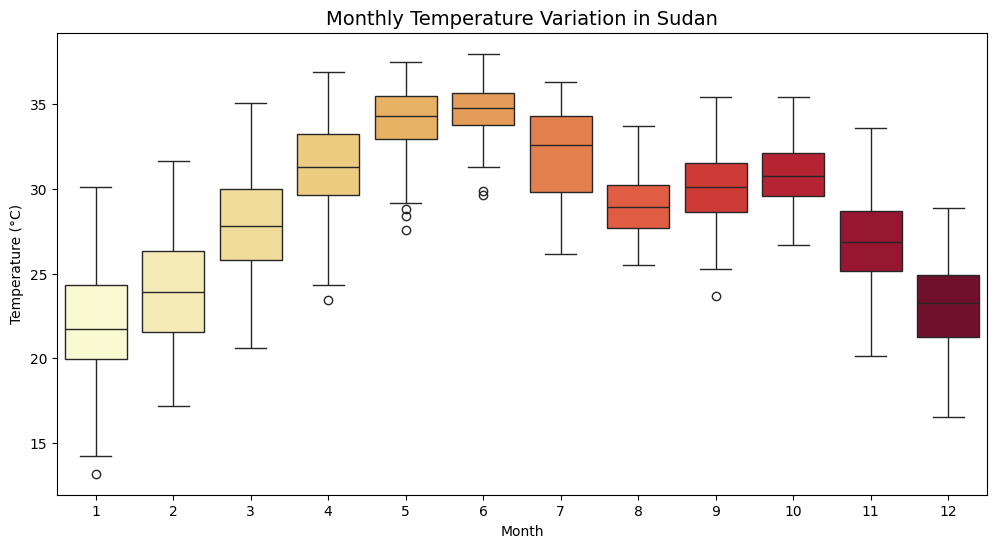

In [4]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Month', y='T2M', data=df, hue='Month', palette='YlOrRd', legend=False)
plt.title('Monthly Temperature Variation in Sudan', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.show()

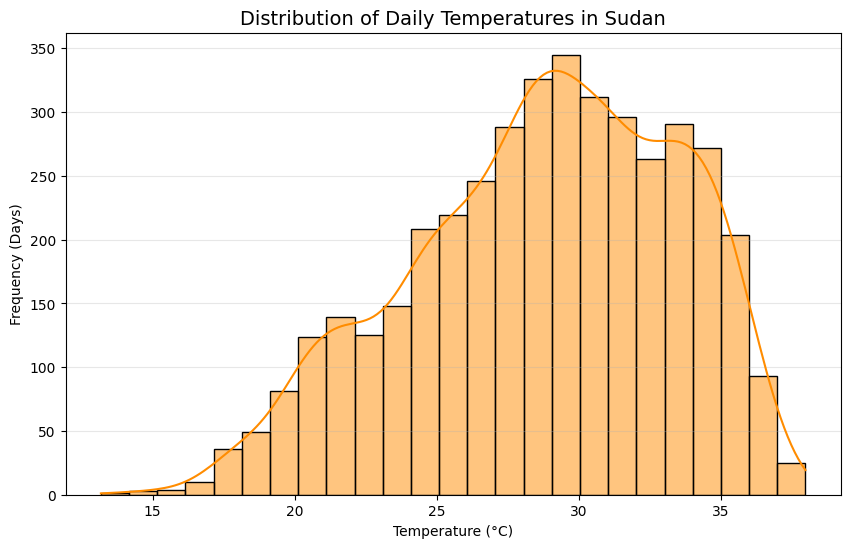

In [5]:
plt.figure(figsize=(10, 6))
# Using a "warm" color to reflect Sudan's climate
sns.histplot(df['T2M'], bins=25, kde=True, color='darkorange')

plt.title('Distribution of Daily Temperatures in Sudan', fontsize=14)
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency (Days)')
plt.grid(axis='y', alpha=0.3)
plt.show()

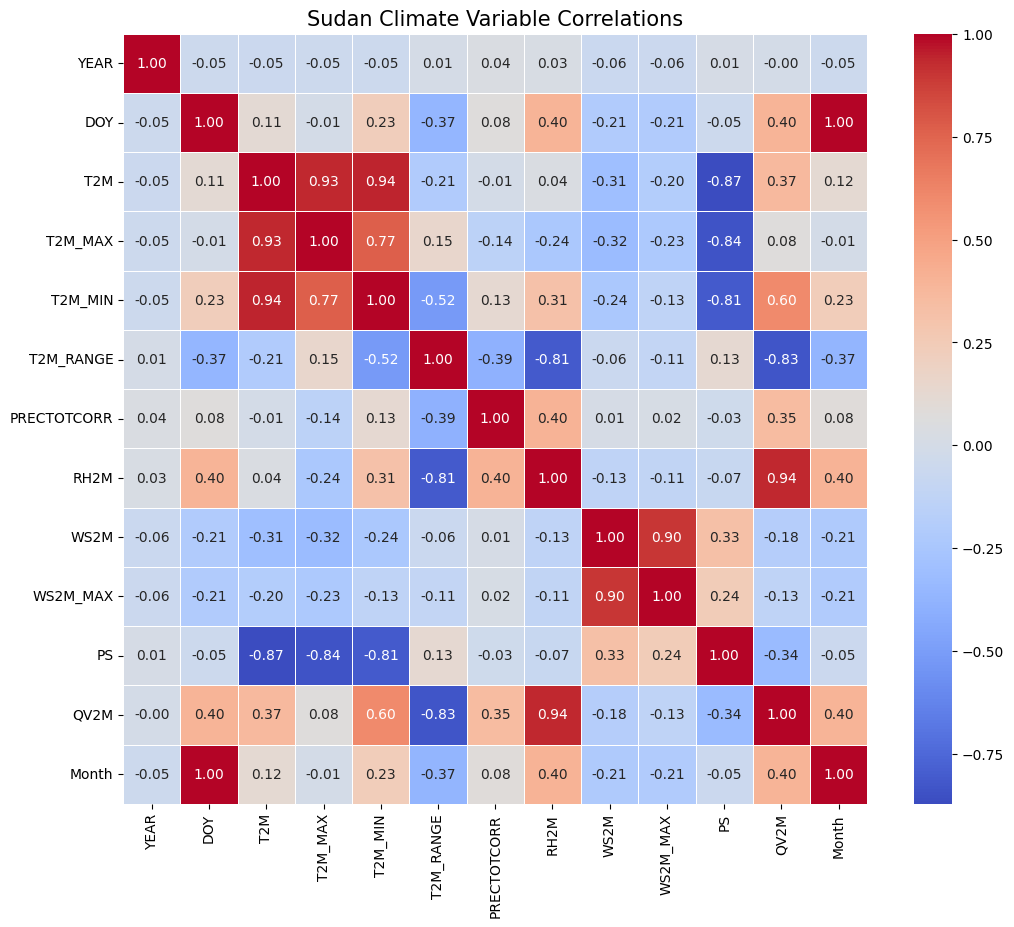

In [7]:
plt.figure(figsize=(12, 10))

# The magic fix: numeric_only=True
corr = df.corr(numeric_only=True)

# Plotting the heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Sudan Climate Variable Correlations', fontsize=15)
plt.show()

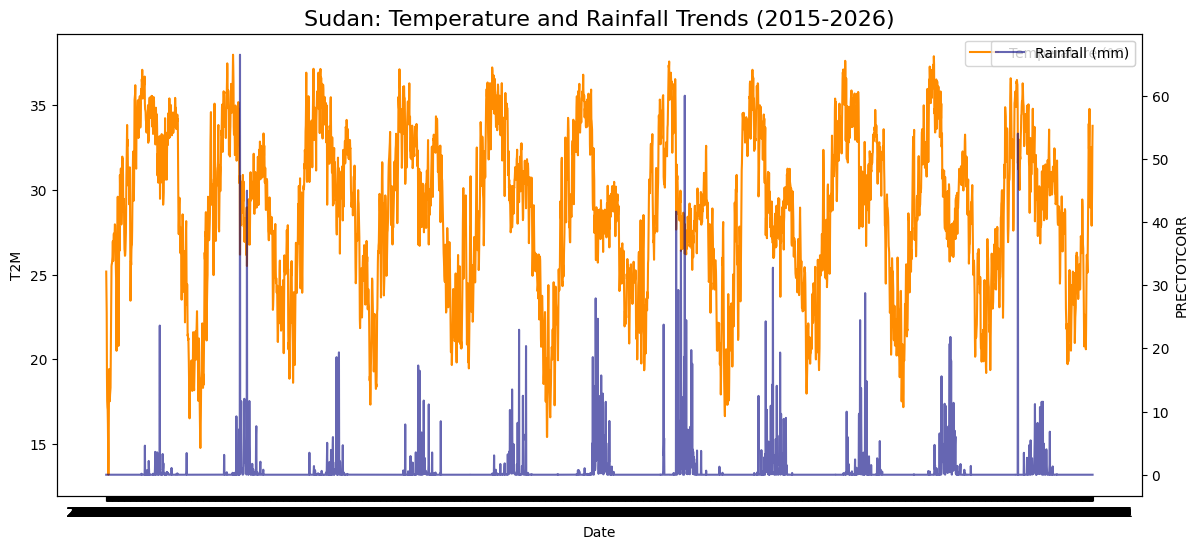

In [8]:
plt.figure(figsize=(14, 6))

# Plotting Temperature for Sudan
sns.lineplot(x='Date', y='T2M', data=df, color='darkorange', label='Temperature (°C)')

# Creating the second Y-axis for Rainfall
plt.twinx()
# Sudan's rain will look like very small, rare needles on this graph
sns.lineplot(x='Date', y='PRECTOTCORR', data=df, color='navy', alpha=0.6, label='Rainfall (mm)')

plt.title('Sudan: Temperature and Rainfall Trends (2015-2026)', fontsize=16)
plt.xlabel('Year')
plt.show()